## About
Chatgpt translation of spec_coherence_example.m

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.ndimage import uniform_filter

In [2]:
# Define the various functions
bigt = 10
numpts = 1000
mysig = 0.5
numens = 100
t = np.linspace(0, bigt, numpts + 1).T
t=t[:-1]

# Preallocate
Sf1f1 = np.zeros((numpts, numens), dtype=complex)
Sf1bf1b = np.zeros((numpts, numens), dtype=complex)
Sf2f2 = np.zeros((numpts, numens), dtype=complex)
Sf3f3 = np.zeros((numpts, numens), dtype=complex)
Sf1f2 = np.zeros((numpts, numens), dtype=complex)
Sf1bf2 = np.zeros((numpts, numens), dtype=complex)
Sf1f3 = np.zeros((numpts, numens), dtype=complex)
Sf1bf3 = np.zeros((numpts, numens), dtype=complex)
Sf2f3 = np.zeros((numpts, numens), dtype=complex)

# Ensemble loop
for k in range(numens):

    f1 = np.cos(2*np.pi*t/0.5) + 1e-3*np.random.randn(numpts)
    f1b = f1 + mysig*np.random.randn(numpts)
    f2 = np.exp(-((t - 0.5*bigt)/(0.1*bigt))**2) + 1e-3*np.random.randn(numpts)
    f3 = np.exp(-((t - 0.5*bigt)/(0.1*bigt))**2) * np.cos(2*np.pi*t/0.5) \
         + 1e-3*np.random.randn(numpts)

    F1 = np.fft.fft(f1)
    F1b = np.fft.fft(f1b)
    F2 = np.fft.fft(f2)
    F3 = np.fft.fft(f3)

    Sf1f1[:, k] = F1 * np.conj(F1)
    Sf1bf1b[:, k] = F1b * np.conj(F1b)
    Sf2f2[:, k] = F2 * np.conj(F2)
    Sf3f3[:, k] = F3 * np.conj(F3)
    Sf1f2[:, k] = F1 * np.conj(F2)
    Sf1bf2[:, k] = F1b * np.conj(F2)
    Sf1f3[:, k] = F1 * np.conj(F3)
    Sf1bf3[:, k] = F1b * np.conj(F3)
    Sf2f3[:, k] = F2 * np.conj(F3)

# Ensemble means
Sf1f1 = Sf1f1.mean(axis=1)
Sf1bf1b = Sf1bf1b.mean(axis=1)
Sf2f2 = Sf2f2.mean(axis=1)
Sf3f3 = Sf3f3.mean(axis=1)
Sf1f2 = Sf1f2.mean(axis=1)
Sf1f3 = Sf1f3.mean(axis=1)
Sf2f3 = Sf2f3.mean(axis=1)
Sf1bf2 = Sf1bf2.mean(axis=1)
Sf1bf3 = Sf1bf3.mean(axis=1)

# Spectral coherence
Cf1f2 = np.abs(Sf1f2) / (np.sqrt(Sf1f1) * np.sqrt(Sf2f2))
Cf1bf2 = np.abs(Sf1bf2) / (np.sqrt(Sf1bf1b) * np.sqrt(Sf2f2))
Cf1f3 = np.abs(Sf1f3) / (np.sqrt(Sf1f1) * np.sqrt(Sf3f3))
Cf1bf3 = np.abs(Sf1bf3) / (np.sqrt(Sf1bf1b) * np.sqrt(Sf3f3))
Cf2f3 = np.abs(Sf2f3) / (np.sqrt(Sf2f2) * np.sqrt(Sf3f3))

# Build spectra from last realization
sp1 = F1 * np.conj(F1)
sp1b = F1b * np.conj(F1b)
sp2 = F2 * np.conj(F2)
sp3 = F3 * np.conj(F3)

# Frequency axis
dom = 2*np.pi/bigt
numoms = 100
oms = np.arange(numoms + 1) * dom

/home/hana/miniconda3/envs/py312/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/hana/miniconda3/envs/py312/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


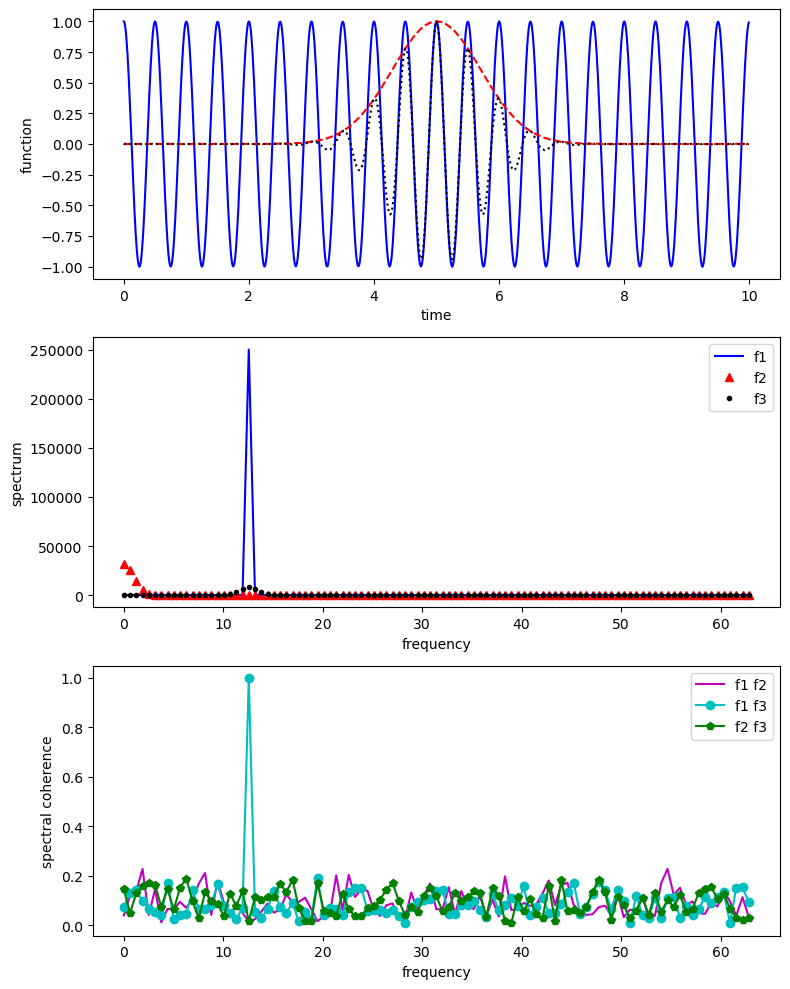

In [3]:
plt.figure(1, figsize=(8,10))

plt.subplot(3,1,1)
plt.plot(t, f1, 'b', label='f1')
plt.plot(t, f2, 'r--', label='f2')
plt.plot(t, f3, 'k:', label='f3')
plt.ylabel("function")
plt.xlabel("time")

plt.subplot(3,1,2)
plt.plot(oms, sp1[:numoms+1], 'b')
plt.plot(oms, sp2[:numoms+1], 'r^')
plt.plot(oms, sp3[:numoms+1], 'k.')
plt.ylabel("spectrum")
plt.xlabel("frequency")
plt.legend(['f1','f2','f3'])

plt.subplot(3,1,3)
plt.plot(oms, Cf1f2[:numoms+1], 'm')
plt.plot(oms, Cf1f3[:numoms+1], 'co-')
plt.plot(oms, Cf2f3[:numoms+1], 'gp-')
plt.ylabel("spectral coherence")
plt.xlabel("frequency")
plt.legend(['f1 f2','f1 f3','f2 f3'])

plt.tight_layout()
plt.show()

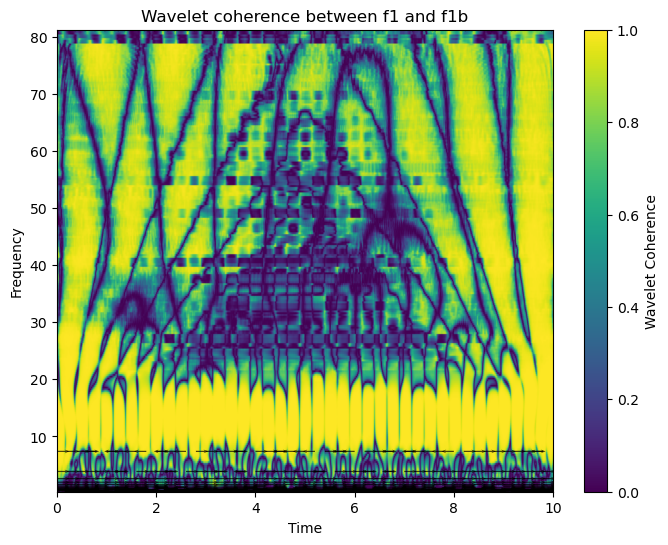

In [17]:
def wavelet_coherence(x, y, dt):
    scales = np.arange(1, 128)
    coeffs_x, freqs = pywt.cwt(x, scales, 'morl', sampling_period=dt)
    coeffs_y, _ = pywt.cwt(y, scales, 'morl', sampling_period=dt)

    Sxx = np.abs(coeffs_x)**2
    Syy = np.abs(coeffs_y)**2
    Sxy = coeffs_x * np.conj(coeffs_y)

    WCOH = np.abs(Sxy)**2 / (Sxx * Syy)

    return WCOH, freqs


def wcoherence_plot(x, y, dt, title, wavelet='morl',
                    scales=np.arange(1, 256),
                    smoothing_scale=5,
                    smoothing_time=5):

    # Continuous wavelet transforms
    Wx, freqs = pywt.cwt(x, scales, wavelet, sampling_period=dt)
    Wy, _     = pywt.cwt(y, scales, wavelet, sampling_period=dt)

    # Cross wavelet spectrum
    Wxy = Wx * np.conj(Wy)

    # Power spectra
    Sxx = np.abs(Wx)**2
    Syy = np.abs(Wy)**2

    # --- Smoothing (very important; MATLAB does this internally) ---
    Sxx_s = uniform_filter(Sxx, size=(smoothing_scale, smoothing_time))
    Syy_s = uniform_filter(Syy, size=(smoothing_scale, smoothing_time))
    Sxy_s = uniform_filter(Wxy.real, size=(smoothing_scale, smoothing_time)) \
          + 1j * uniform_filter(Wxy.imag, size=(smoothing_scale, smoothing_time))

    # Magnitude-squared wavelet coherence
    WCOH = np.abs(Sxy_s)**2 / (Sxx_s * Syy_s)

    # Phase difference
    phase = np.angle(Sxy_s)

    # ---- Plot ----
    plt.figure(figsize=(8,6))

    extent = [0, len(x)*dt, freqs.min(), freqs.max()]
    plt.imshow(WCOH,
               extent=extent,
               origin='lower',
               aspect='auto',
               cmap='viridis',
               vmin=0, vmax=1)

    plt.colorbar(label='Wavelet Coherence')
    plt.ylabel('Frequency')
    plt.xlabel('Time')

    # Optional phase arrows (decimated to avoid clutter)
    skip = (slice(None, None, 10), slice(None, None, 20))
    t_axis = np.arange(len(x)) * dt
    T, F = np.meshgrid(t_axis, freqs)

    plt.quiver(T[skip], F[skip],
               np.cos(phase)[skip],
               np.sin(phase)[skip],
               scale=40, headwidth=3, headlength=4,
               headaxislength=3, alpha=0.7)

    plt.title(title)
    return WCOH, freqs


dt = t[1] - t[0]

# f1 vs f1b
# WCOH, freqs = wavelet_coherence(f1, f1b, dt)
WCOH, freqs = wcoherence_plot(f1, f1b, dt, "Wavelet coherence between f1 and f1b")

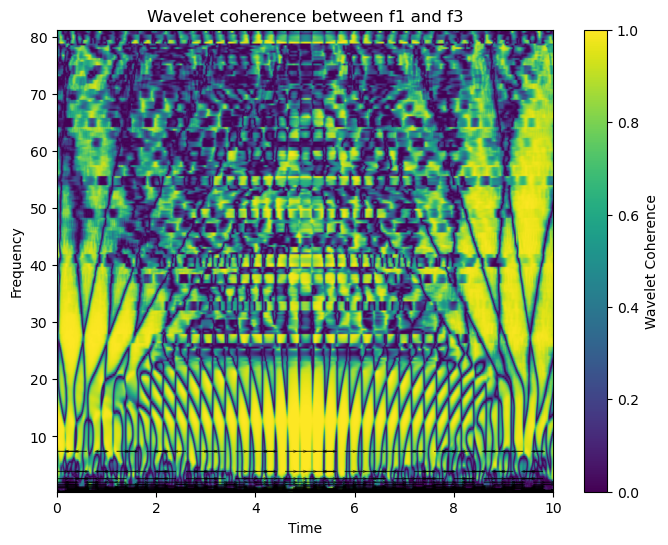

In [18]:
# f1 vs f3
WCOH, freqs = wcoherence_plot(f1, f3, dt, "Wavelet coherence between f1 and f3")

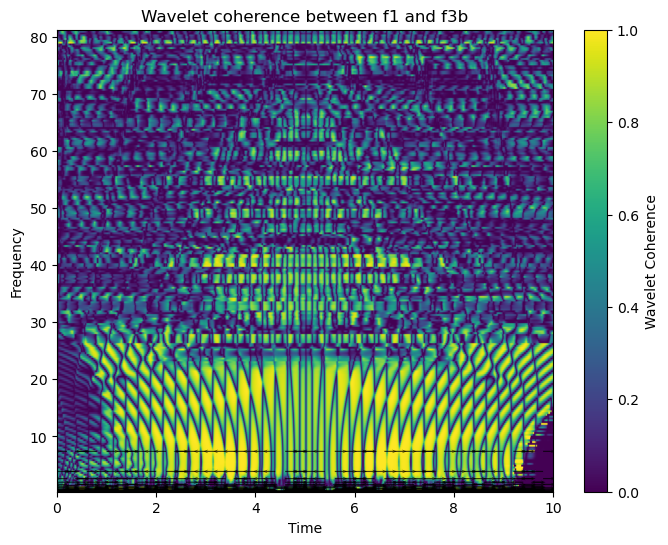

In [19]:
# f1 vs f3b
f3b = np.exp(-((t-0.5*bigt)/(0.1*bigt))**2) * np.sin(2*np.pi*t/0.5)
WCOH, freqs = wcoherence_plot(f1, f3b, dt, "Wavelet coherence between f1 and f3b")